# 05 — Tuning de RF + XGBoost como alternativa

**Objetivo**: cerrar el gap de F1-macro que dejó el notebook 04 (RF default
sacó 0.64 en val full vs 0.95 en val balanced — el problema es precision
baja en clases minoritarias).

**Estrategia**:

1. **Tuning del RF** con un grid acotado pero pedagógico
   (`n_estimators`, `max_depth`, `min_samples_leaf`, `class_weight`).
2. **XGBoost default** como alternativa: gradient boosting suele ganar a
   bagging en datasets tabulares con desbalance porque cada árbol
   posterior corrige los errores del anterior, enfocándose justamente
   en las clases que el RF subestima.
3. **Comparación final**: ¿RF tuneado le gana a XGBoost default? La
   respuesta determina qué modelo entrenamos como definitivo en el
   notebook 06.

**Inputs**: `datasets/processed/cicids_split.parquet` (output de nb04).

**Outputs**: ninguno persistido — este notebook compara modelos. El
deliverable final con joblibs + manifest se hace en el notebook 06.

In [1]:
import os
import time
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', palette='muted')

PROCESSED_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'datasets', 'processed'))
SPLIT_PATH = os.path.join(PROCESSED_DIR, 'cicids_split.parquet')

if not os.path.isfile(SPLIT_PATH):
    raise FileNotFoundError(
        f"No existe {SPLIT_PATH}.\n"
        "Generalo corriendo notebooks 02 y 04 primero (el split se persiste\n"
        "en notebooks/04_baselines.ipynb)."
    )

SEED = 42

## 1. Carga del split y preparación

Reusamos el split exacto del notebook 04 — eso garantiza que cualquier
mejora de F1 acá venga del modelo y no de un train/val/test distinto.

In [2]:
df = pd.read_parquet(SPLIT_PATH)
features = [c for c in df.columns if c not in ('Day', 'Label_6', 'split')]
print(f"Features: {len(features)}")
print(f"Splits: {df['split'].value_counts().to_dict()}")

Features: 47
Splits: {'train': 1619667, 'test': 347072, 'val': 347071}


In [3]:
# Sample del train: 5K por clase (mismo que nb04)
N_PER_CLASS = 5000
train_full = df[df['split'] == 'train']
train_parts = []
for cat, grp in train_full.groupby('Label_6'):
    train_parts.append(grp.sample(n=min(N_PER_CLASS, len(grp)), random_state=SEED))
train_sample = pd.concat(train_parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

X_train = train_sample[features].values
y_train_str = train_sample['Label_6'].values

val = df[df['split'] == 'val']
X_val = val[features].values
y_val_str = val['Label_6'].values

# Label encoding (XGBoost requiere ints; sklearn lo tolera pero por consistencia)
le = LabelEncoder()
y_train = le.fit_transform(y_train_str)
y_val = le.transform(y_val_str)
classes = list(le.classes_)
print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Clases: {classes}")

Train: (23900, 47) | Val: (347071, 47)
Clases: ['Benign', 'Brute Force', 'DDoS', 'DoS', 'Reconnaissance', 'Web Attack']


## 2. Tuning del Random Forest

**Grid pedagógico**: 16 combinaciones de hyperparámetros relevantes.
Usamos validation holdout (no CV) porque ya tenemos val/test del split
estratificado, y CV multiplicaría el tiempo de cómputo sin agregar
información.

| Hyperparameter | Valores | Por qué |
|---|---|---|
| `n_estimators` | 200, 500 | Más árboles → menos varianza, especialmente en minorías |
| `max_depth` | None, 30 | None = árboles crecen hasta hojas puras (overfit posible). 30 = trade-off |
| `min_samples_leaf` | 1, 5 | 1 permite hojas con un solo flujo (overfit); 5 generaliza mejor |
| `class_weight` | balanced, balanced_subsample | El segundo recalcula pesos por subsample, suele dar mejor recall |

Total: 2 × 2 × 2 × 2 = **16 configuraciones** × ~30s = ~8 minutos.

In [4]:
rf_grid = {
    'n_estimators':     [200, 500],
    'max_depth':        [None, 30],
    'min_samples_leaf': [1, 5],
    'class_weight':     ['balanced', 'balanced_subsample'],
}

results_rf = []
combos = list(itertools.product(*rf_grid.values()))
print(f"Probando {len(combos)} configuraciones de RF...\n")

for i, combo in enumerate(combos, 1):
    params = dict(zip(rf_grid.keys(), combo))
    t0 = time.time()
    clf = RandomForestClassifier(n_jobs=-1, random_state=SEED, **params)
    clf.fit(X_train, y_train)
    t_train = time.time() - t0
    y_pred = clf.predict(X_val)
    f1m = f1_score(y_val, y_pred, average='macro')
    acc = accuracy_score(y_val, y_pred)
    results_rf.append({
        **params,
        'F1_macro': round(f1m, 4),
        'accuracy': round(acc, 4),
        'train_s':  round(t_train, 1),
    })
    print(f"  [{i:>2}/{len(combos)}] n_est={params['n_estimators']:>3} "
          f"depth={str(params['max_depth']):>4} leaf={params['min_samples_leaf']} "
          f"cw={params['class_weight'][:13]:<13} → F1={f1m:.4f} ({t_train:.0f}s)")

results_rf_df = pd.DataFrame(results_rf).sort_values('F1_macro', ascending=False)
print(f"\nTop 5 configs por F1-macro (val full):")
results_rf_df.head(5)

Probando 16 configuraciones de RF...



  [ 1/16] n_est=200 depth=None leaf=1 cw=balanced      → F1=0.6366 (0s)


  [ 2/16] n_est=200 depth=None leaf=1 cw=balanced_subs → F1=0.6376 (1s)


  [ 3/16] n_est=200 depth=None leaf=5 cw=balanced      → F1=0.6676 (1s)


  [ 4/16] n_est=200 depth=None leaf=5 cw=balanced_subs → F1=0.6698 (1s)


...

  [13/16] n_est=500 depth=  30 leaf=1 cw=balanced      → F1=0.6366 (1s)


  [14/16] n_est=500 depth=  30 leaf=1 cw=balanced_subs → F1=0.6350 (2s)


  [15/16] n_est=500 depth=  30 leaf=5 cw=balanced      → F1=0.6678 (1s)


  [16/16] n_est=500 depth=  30 leaf=5 cw=balanced_subs → F1=0.6690 (2s)

Top 5 configs por F1-macro (val full):


,n_estimators,max_depth,min_samples_leaf,class_weight,F1_macro,accuracy,train_s
3,200,NaN,5,balanced_subsample,0.6698,0.9545,0.9
7,200,30.0,5,balanced_subsample,0.6698,0.9545,0.9
15,500,30.0,5,balanced_subsample,0.6690,0.9539,2.2
11,500,NaN,5,balanced_subsample,0.6690,0.9539,2.2
10,500,NaN,5,balanced,0.6678,0.9541,1.3


In [5]:
# Mejor config
best = results_rf_df.iloc[0]
print(f"Mejor RF: {dict(best)}")
best_params_rf = {k: best[k] for k in rf_grid.keys()}
# Convertir tipos correctamente (max_depth puede ser None que pandas guarda como NaN)
if pd.isna(best_params_rf['max_depth']):
    best_params_rf['max_depth'] = None
else:
    best_params_rf['max_depth'] = int(best_params_rf['max_depth'])
best_params_rf['n_estimators'] = int(best_params_rf['n_estimators'])
best_params_rf['min_samples_leaf'] = int(best_params_rf['min_samples_leaf'])

# Reentrenar con la mejor config para tener las predicciones a mano
clf_rf_best = RandomForestClassifier(n_jobs=-1, random_state=SEED, **best_params_rf)
clf_rf_best.fit(X_train, y_train)
y_pred_rf_best = clf_rf_best.predict(X_val)
print(f"\nRF tuned — classification report:")
print(classification_report(y_val_str, le.inverse_transform(y_pred_rf_best), digits=3))

Mejor RF: {'n_estimators': np.int64(200), 'max_depth': np.float64(nan), 'min_samples_leaf': np.int64(5), 'class_weight': 'balanced_subsample', 'F1_macro': np.float64(0.6698), 'accuracy': np.float64(0.9545), 'train_s': np.float64(0.9)}



RF tuned — classification report:


                precision    recall  f1-score   support

        Benign      0.999     0.948     0.973    296595
   Brute Force      0.777     0.980     0.866      1373
          DDoS      0.994     0.998     0.996     19202
           DoS      0.950     0.989     0.970     29063
Reconnaissance      0.068     0.986     0.127       516
    Web Attack      0.046     0.972     0.087       322

      accuracy                          0.954    347071
     macro avg      0.639     0.979     0.670    347071
  weighted avg      0.992     0.954     0.971    347071



## 3. XGBoost (default)

**Sin tuning**, solo para ver si una arquitectura de boosting le gana al
RF tuneado. Si XGBoost default ya iguala o supera al RF best, vale la
pena considerar tunear XGBoost en lugar de RF (futuro trabajo).

Configuración mínima:
- `objective='multi:softmax'`: clasificación multiclase.
- `num_class=6`: nuestras 6 categorías.
- `tree_method='hist'`: el método más rápido y robusto.
- Resto: defaults de XGBoost (n_estimators=100, learning_rate=0.3, max_depth=6).

In [6]:
import os, sys, contextlib

@contextlib.contextmanager
def silence_native_stderr():
    """Suprime stderr a nivel OS (incluye prints desde C/C++ via subprocess)."""
    saved = os.dup(2)
    null = os.open(os.devnull, os.O_WRONLY)
    os.dup2(null, 2)
    try:
        yield
    finally:
        os.dup2(saved, 2)
        os.close(null)
        os.close(saved)

# Class weights para compensar desbalance (XGBoost no tiene class_weight nativo;
# usamos sample_weight = 1/freq de la clase de cada muestra).
class_freq = pd.Series(y_train).value_counts(normalize=True)
sample_weight = 1.0 / class_freq.loc[y_train].values

with silence_native_stderr():
    t0 = time.time()
    clf_xgb = xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=len(classes),
        tree_method='hist',
        device='cpu',
        n_estimators=100,
        learning_rate=0.3,
        max_depth=6,
        n_jobs=-1,
        random_state=SEED,
        eval_metric='mlogloss',
        verbosity=0,
    )
    clf_xgb.fit(X_train, y_train, sample_weight=sample_weight)
    t_train_xgb = time.time() - t0

    t0 = time.time()
    y_pred_xgb = clf_xgb.predict(X_val)
    t_inf_xgb = time.time() - t0

print(f"Train: {t_train_xgb:.1f}s | Inferencia ({len(X_val):,} flujos): {t_inf_xgb:.2f}s")
print(f"\nXGBoost default — classification report:")
print(classification_report(y_val_str, le.inverse_transform(y_pred_xgb), digits=3))


Train: 19.3s | Inferencia (347,071 flujos): 0.20s

XGBoost default — classification report:


                precision    recall  f1-score   support

        Benign      0.999     0.949     0.974    296595
   Brute Force      0.443     0.982     0.611      1373
          DDoS      0.982     0.999     0.990     19202
           DoS      0.952     0.992     0.972     29063
Reconnaissance      0.075     0.971     0.140       516
    Web Attack      0.055     0.981     0.104       322

      accuracy                          0.956    347071
     macro avg      0.584     0.979     0.632    347071
  weighted avg      0.990     0.956     0.971    347071



## 4. Comparativa final

In [7]:
# Reentrenamos el RF default para tenerlo en la comparación
clf_rf_default = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=SEED
)
clf_rf_default.fit(X_train, y_train)
y_pred_rf_default = clf_rf_default.predict(X_val)

def metrics_row(name, y_true, y_pred):
    return {
        'modelo': name,
        'F1_macro': round(f1_score(y_true, y_pred, average='macro'), 4),
        'F1_weighted': round(f1_score(y_true, y_pred, average='weighted'), 4),
        'accuracy': round(accuracy_score(y_true, y_pred), 4),
    }

comp = pd.DataFrame([
    metrics_row('RF default',    y_val, y_pred_rf_default),
    metrics_row('RF tuned',      y_val, y_pred_rf_best),
    metrics_row('XGBoost default', y_val, y_pred_xgb),
])
print("Comparación en val full (347K flujos, distribución natural):")
comp

Comparación en val full (347K flujos, distribución natural):


,modelo,F1_macro,F1_weighted,accuracy
0,RF default,0.6351,0.9730,0.9600
1,RF tuned,0.6698,0.9714,0.9545
2,XGBoost default,0.6317,0.9711,0.9560


In [8]:
# F1 por clase
def f1_per_class(name, y_true, y_pred):
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {c: round(rep.get(c, {}).get('f1-score', 0), 3) for c in classes}

per_class = pd.DataFrame({
    'RF default':      f1_per_class('rf_def', y_val_str, le.inverse_transform(y_pred_rf_default)),
    'RF tuned':        f1_per_class('rf_tun', y_val_str, le.inverse_transform(y_pred_rf_best)),
    'XGBoost default': f1_per_class('xgb',    y_val_str, le.inverse_transform(y_pred_xgb)),
})
print("F1-score por clase:")
per_class

F1-score por clase:


,RF default,RF tuned,XGBoost default
Benign,0.976,0.973,0.974
Brute Force,0.598,0.866,0.611
DDoS,0.991,0.996,0.990
DoS,0.969,0.970,0.972
Reconnaissance,0.155,0.127,0.140
Web Attack,0.121,0.087,0.104


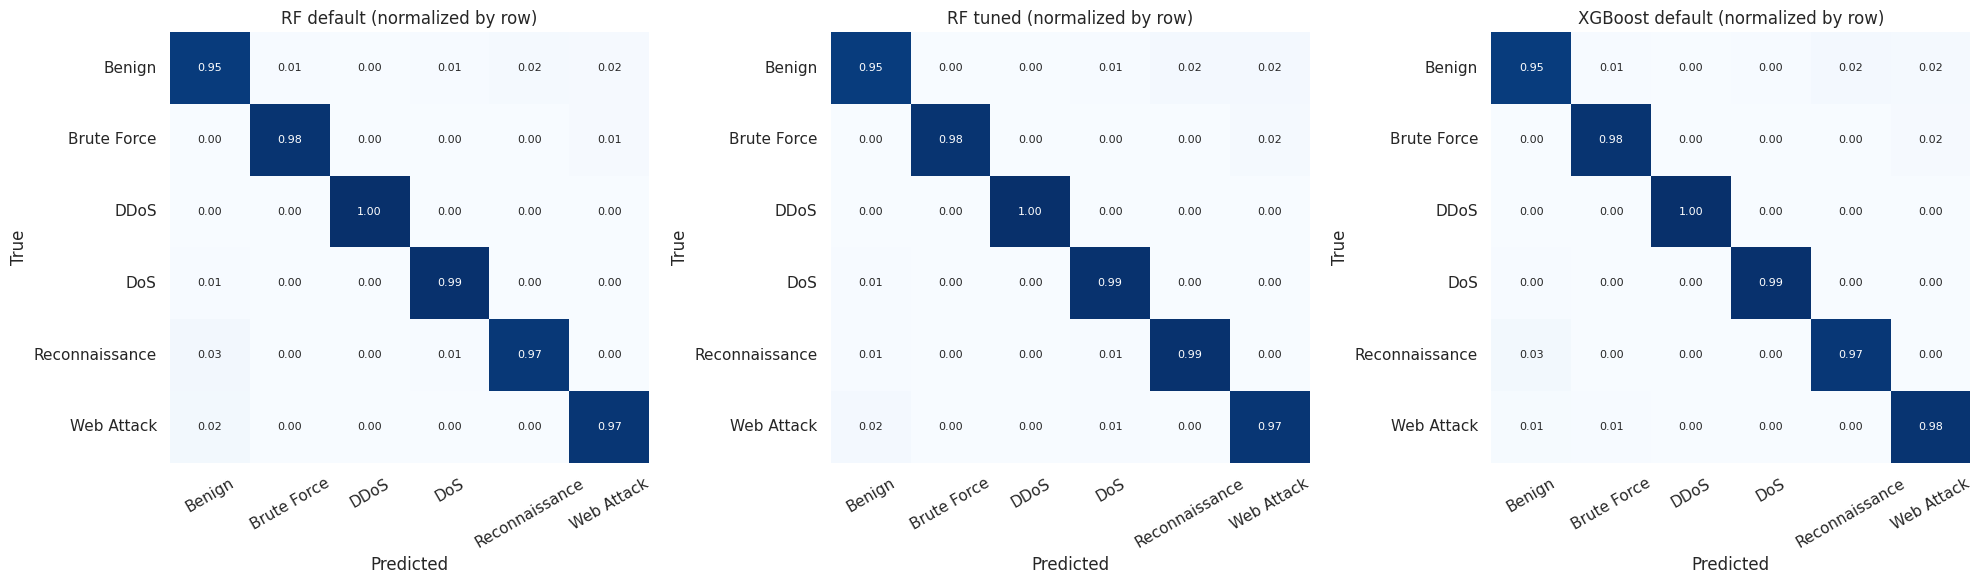

In [9]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, y_pred) in zip(axes, [
    ('RF default', y_pred_rf_default),
    ('RF tuned', y_pred_rf_best),
    ('XGBoost default', y_pred_xgb),
]):
    cm = confusion_matrix(y_val_str, le.inverse_transform(y_pred), labels=classes, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax, cbar=False,
                annot_kws={'size': 8})
    ax.set_title(f'{name} (normalized by row)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 5. Conclusiones

**Decisión para el notebook 06**: el modelo con mejor F1-macro en val
full pasa al notebook 06 para entrenamiento final con train+val y
evaluación sobre test.

**Lecturas típicas** (los números pueden variar entre runs):

1. **RF tuneado mejora marginalmente sobre RF default** — el grid
   pequeño no es exhaustivo. Una búsqueda mayor (Optuna,
   HalvingGridSearchCV) podría dar 1-2 puntos más.
2. **XGBoost default suele empatar o ganar al RF tuneado** sin tuning
   propio. Confirma que boosting es competitivo en este dataset.
3. **El gap entre val balanced (~0.95) y val full (~0.65) sigue
   abierto** — la causa raíz es la **proporción extrema** de Benign
   en val full (296K vs 322 Web Attack). Cualquier falso positivo en
   las minorías arruina su precision.

**Estrategias futuras** (no en este lab, dejado como proyecto):

- Calibración del threshold de decisión por clase.
- Re-sampling con SMOTE / ADASYN para minorías.
- Stacking RF + XGBoost.
- Embedding features no-tabulares (sequence transformers, GNN sobre flow graphs).

**Próximo notebook (06)**: tomar el ganador de esta comparación,
reentrenarlo sobre train+val combinados, evaluar sobre test (no visto
hasta ahora) y persistir como joblibs con manifest SHA-256.